# Multilingual Health Question Answering
## Experiment 1 — Data Exploration & TF-IDF Retrieval Baseline

**Author:** Samuel Mwania  
**Competition:** [Multilingual Health QA in Low-Resource African Languages](https://zindi.africa) — Zindi  
**Date:** June, 4th 2026  

---

### Context

The task: given a health question in one of five African languages — **Amharic, Luganda, Akan, Swahili, or English** — generate a fluent, accurate answer *in the same language*. Submissions are scored on ROUGE-L F1, ROUGE-1 F1, and an LLM-as-judge metric.

This is the first in a series of experiments. Before reaching for a fine-tuned seq2seq model, this notebook establishes what the data actually looks like and sets a retrieval-based floor to measure later work against.

### Objectives

- Map the structure, distribution, and quirks of the multilingual dataset
- Surface language-specific patterns and the preprocessing they demand
- Establish a **TF-IDF retrieval baseline** as a reproducible reference point
- Capture findings that will steer modelling and fine-tuning decisions downstream

### Notebook structure

| Section | Focus |
|---|---|
| 1 | Imports & configuration |
| 2 | Data loading & initial inspection |
| 3 | Exploratory analysis — language distribution, answer length, question types |
| 4 | Text preprocessing analysis |
| 5 | TF-IDF retrieval baseline — build, generate, submit |

> **Why start with retrieval?** A TF-IDF nearest-neighbour baseline is fast, transparent, and language-agnostic at the character level. It tells us how far simple lookup gets us — and any model that can't beat it isn't earning its complexity.

In [2]:
# Standard library
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# NLP baseline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# Display settings
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries loaded successfully")

All libraries loaded successfully


## 1. Data Loading and Initial Inspection

Load the three splits provided by the competition organizers:
- **Train.csv** — 29,815 QA pairs used for model training
- **Val.csv** — 6,686 QA pairs used for validation during training
- **Test.csv** — 2,618 questions only — I must generate the answers

I first inspect the shape, columns, data types, and a few sample rows to understand the structure before any analysis.

In [3]:
# Load all three splits
DATA_DIR = '../data/raw'

train_df = pd.read_csv(os.path.join(DATA_DIR, 'Train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'Val.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'Test.csv'))

print("=" * 60)
print("DATASET SHAPES")
print("=" * 60)
print(f"Train : {train_df.shape[0]:>6,} rows x {train_df.shape[1]} columns")
print(f"Val   : {val_df.shape[0]:>6,} rows x {val_df.shape[1]} columns")
print(f"Test  : {test_df.shape[0]:>6,} rows x {test_df.shape[1]} columns")
print()
print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)
print("Train columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

DATASET SHAPES
Train : 29,815 rows x 4 columns
Val   :  6,686 rows x 4 columns
Test  :  2,618 rows x 3 columns

COLUMN NAMES
Train columns: ['ID', 'input', 'output', 'subset']
Test columns : ['ID', 'input', 'subset']


In [4]:
# Inspect data types and null values
print("=" * 60)
print("TRAIN — DATA TYPES AND NULL CHECK")
print("=" * 60)
print(train_df.dtypes)
print()
print("Null values in train:")
print(train_df.isnull().sum())
print()
print("Null values in val:")
print(val_df.isnull().sum())
print()
print("Null values in test:")
print(test_df.isnull().sum())

TRAIN — DATA TYPES AND NULL CHECK
ID        object
input     object
output    object
subset    object
dtype: object

Null values in train:
ID        0
input     0
output    0
subset    0
dtype: int64

Null values in val:
ID        0
input     0
output    0
subset    0
dtype: int64

Null values in test:
ID        0
input     0
subset    0
dtype: int64


In [5]:
# Look at the first few rows
print("SAMPLE TRAINING ROWS")
train_df.head(5)

SAMPLE TRAINING ROWS


,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye w...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na w...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde redi dwuma yiye?","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no boa ma asiane so tew?,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a ɛwɔ STI ne HIV a ɛb...",Aka_Gha
3,ID_TR_Aka_Gha_BDD640FB,"Dɛn ne aduru a wodi si nyisɛn ano ntɛm ntɛm, na ɛyɛ adwuma sɛn?",Aduru a wodi si nyisɛn ano ntɛm ntɛm (Emergency contraception (EC)) kyerɛ akwan a wɔfa so siw nyinsɛn ano wɔ nna a...,Aka_Gha
4,ID_TR_Aka_Gha_46685257,"Hu sɛnea ɛyɛ den sɛ wubehu bɔbea mu basabasayɔ (GBV) na woayɛ ho biribi, na si hia a ɛho hia sɛ wohwehwɛ mmoa so dua.","Ɛnyɛ mmerɛw bere nyinaa sɛ wubehu bɔbea mu basabasayɔ (GBV), nanso kae sɛ, mmoa a wobɛhwehwɛ no yɛ ahoɔden ho sɛnkye...",Aka_Gha


## 2. Exploratory Data Analysis

### 2.1 Language Distribution

The `subset` column encodes the language-country configuration. Understanding how many examples exist per language is critical because:
- Low-resource languages with few examples will be harder to learn
- Class imbalance may require weighted sampling or targeted augmentation
- The test set distribution should be compared against train to detect any shift

In [6]:
# Language distribution across splits
print("=" * 60)
print("LANGUAGE (SUBSET) DISTRIBUTION")
print("=" * 60)

train_dist = train_df['subset'].value_counts().sort_index()
test_dist = test_df['subset'].value_counts().sort_index()

dist_df = pd.DataFrame({
    'Train': train_dist,
    'Train %': (train_dist / len(train_df) * 100).round(2),
    'Test': test_dist,
    'Test %': (test_dist / len(test_df) * 100).round(2)
}).fillna(0)

print(dist_df)
print()
print(f"Number of unique language configs in train: {train_df['subset'].nunique()}")
print(f"Number of unique language configs in test : {test_df['subset'].nunique()}")

LANGUAGE (SUBSET) DISTRIBUTION
         Train  Train %  Test  Test %
subset                               
Aka_Gha   4455    14.94   492   18.79
Amh_Eth   1845     6.19    61    2.33
Eng_Eth   3915    13.13    60    2.29
Eng_Gha   4443    14.90   491   18.75
Eng_Ken   2080     6.98   167    6.38
Eng_Uga   7624    25.57   744   28.42
Lug_Uga   3383    11.35   374   14.29
Swa_Ken   2070     6.94   229    8.75

Number of unique language configs in train: 8
Number of unique language configs in test : 8


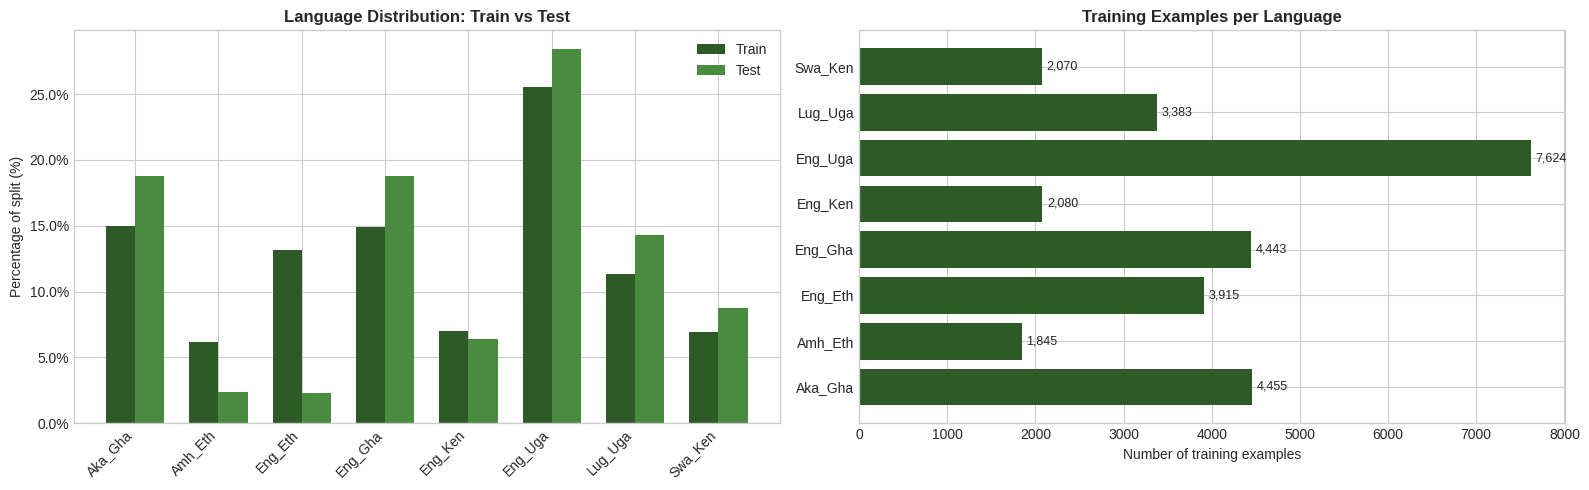

Saved plot to docs/language_distribution.png


In [7]:
# Visualize language distribution: train vs test
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: side by side counts
x = np.arange(len(dist_df))
width = 0.35
axes[0].bar(x - width/2, dist_df['Train %'], width, label='Train', color='#2d5a27')
axes[0].bar(x + width/2, dist_df['Test %'], width, label='Test', color='#4a8c3f')
axes[0].set_xticks(x)
axes[0].set_xticklabels(dist_df.index, rotation=45, ha='right')
axes[0].set_ylabel('Percentage of split (%)')
axes[0].set_title('Language Distribution: Train vs Test', fontweight='bold')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Plot 2: train counts
axes[1].barh(dist_df.index, dist_df['Train'], color='#2d5a27')
axes[1].set_xlabel('Number of training examples')
axes[1].set_title('Training Examples per Language', fontweight='bold')
for i, v in enumerate(dist_df['Train']):
    axes[1].text(v + 50, i, f'{int(v):,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/language_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved plot to docs/language_distribution.png")

### 2.2 Question and Answer Length Analysis

Understanding text length distributions is critical for fine-tuning decisions:
- **Input (question) length** determines the encoder max token length
- **Output (answer) length** determines the decoder max generation length
- Setting these too low truncates content and hurts ROUGE; too high wastes compute and memory

Measure length in both characters and whitespace-separated tokens, broken down by language since different languages have different typical lengths.

In [8]:
# Compute length statistics in characters and words
train_df['input_char_len'] = train_df['input'].str.len()
train_df['output_char_len'] = train_df['output'].str.len()
train_df['input_word_len'] = train_df['input'].str.split().str.len()
train_df['output_word_len'] = train_df['output'].str.split().str.len()

print("=" * 60)
print("INPUT (QUESTION) LENGTH — WORDS")
print("=" * 60)
print(train_df['input_word_len'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1))
print()
print("=" * 60)
print("OUTPUT (ANSWER) LENGTH — WORDS")
print("=" * 60)
print(train_df['output_word_len'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1))

INPUT (QUESTION) LENGTH — WORDS
count    29815.0
mean        15.1
std          9.1
min          0.0
50%         13.0
90%         27.0
95%         34.0
99%         49.0
max         83.0
Name: input_word_len, dtype: float64

OUTPUT (ANSWER) LENGTH — WORDS
count    29815.0
mean        76.2
std         58.9
min          1.0
50%         61.0
90%        153.0
95%        184.0
99%        272.0
max        482.0
Name: output_word_len, dtype: float64


In [9]:
# Length statistics broken down by language
length_by_lang = train_df.groupby('subset').agg(
    q_words_median=('input_word_len', 'median'),
    q_words_95=('input_word_len', lambda x: x.quantile(0.95)),
    a_words_median=('output_word_len', 'median'),
    a_words_95=('output_word_len', lambda x: x.quantile(0.95)),
    a_words_max=('output_word_len', 'max')
).round(1)

print("LENGTH STATISTICS BY LANGUAGE (in words)")
print(length_by_lang)

LENGTH STATISTICS BY LANGUAGE (in words)
         q_words_median  q_words_95  a_words_median  a_words_95  a_words_max
subset                                                                      
Aka_Gha            27.0        51.0           100.0       208.3          458
Amh_Eth             9.0        17.0            19.0        34.0          106
Eng_Eth            12.0        21.0            24.0        38.0          118
Eng_Gha            19.0        32.0            70.0       136.0          408
Eng_Ken            11.0        20.0            64.0       170.0          315
Eng_Uga            11.0        18.0            73.0       227.0          482
Lug_Uga            10.0        18.0            68.0       168.0          331
Swa_Ken            11.0        19.0            66.0       192.0          345


### 2.3 Data Quality Check

The length statistics revealed a minimum input length of 0 words and minimum output length of 1 word. These degenerate records (empty or near-empty questions/answers) can harm training by introducing noise. Identify and quantify them here so I can decide on a cleaning strategy.

In [10]:
# Find degenerate records: empty or very short
print("=" * 60)
print("DATA QUALITY ISSUES")
print("=" * 60)

empty_input = train_df[train_df['input_word_len'] == 0]
short_input = train_df[train_df['input_word_len'].between(1, 2)]
short_output = train_df[train_df['output_word_len'].between(0, 2)]

print(f"Records with EMPTY input (0 words)      : {len(empty_input)}")
print(f"Records with VERY SHORT input (1-2 words): {len(short_input)}")
print(f"Records with VERY SHORT output (0-2 words): {len(short_output)}")
print()

# Check for exact duplicate questions
dup_questions = train_df.duplicated(subset=['input'], keep=False).sum()
dup_full = train_df.duplicated(subset=['input', 'output'], keep=False).sum()
print(f"Duplicate questions (input only)        : {dup_questions}")
print(f"Fully duplicate rows (input + output)   : {dup_full}")
print()

# Show the empty input record if it exists
if len(empty_input) > 0:
    print("EMPTY INPUT RECORD(S):")
    print(empty_input[['ID', 'input', 'output', 'subset']].to_string())

DATA QUALITY ISSUES
Records with EMPTY input (0 words)      : 1
Records with VERY SHORT input (1-2 words): 39
Records with VERY SHORT output (0-2 words): 15

Duplicate questions (input only)        : 2928
Fully duplicate rows (input + output)   : 552

EMPTY INPUT RECORD(S):
                           ID input                                                                                                                                                                                                                                                     output   subset
18285  ID_TR_Eng_Uga_E9A002A4        Yes, when Gonorrhea is advanced it becomes harder to  treat. Advanced Gonorrhea involves multiple organs and leads to severe complications such as pus formation which makes it harder to treat and it may even in some cases require surgical operation.  Eng_Uga


In [11]:
# Inspect the very short outputs before deciding to drop
print("=" * 60)
print("VERY SHORT OUTPUTS (0-2 words) — INSPECTION")
print("=" * 60)
short_out = train_df[train_df['output_word_len'].between(0, 2)]
for idx, row in short_out.iterrows():
    print(f"[{row['subset']}] Q: {row['input'][:80]}")
    print(f"          A: {row['output']}")
    print("-" * 60)

VERY SHORT OUTPUTS (0-2 words) — INSPECTION
[Amh_Eth] Q: በትሪኮሞናስ ጥገኛ ተህዋስ ምክንያት ለሚከሰተው የሴት ብልት/ከረቤዛ ቁጣ ወይም ኢንፌክሽን የተለመደ መጠሪያው ምንድን ነው?
          A: ትሪኮሞናል ቫጂናይትስ።
------------------------------------------------------------
[Amh_Eth] Q: በጨብጥ ምክንያት የሚመጣ የጉሮሮ እብጠትና መቅላት ስም ማን ይባላል?
          A: ፋሪንጃይቲስ (Pharyngitis)።
------------------------------------------------------------
[Amh_Eth] Q: ከፍተኛ ተጋላጭነት ላለው የHPV ዋናው የመከላከያ እርምጃ ምንድነው?
          A: የHPV ክትባት::
------------------------------------------------------------
[Amh_Eth] Q: በጥገኛ ተውሳክ የሚከሰተው የትኛው የተለመደ የአባላዘር በሽታ ነው?
          A: Trichomoniasis::
------------------------------------------------------------
[Amh_Eth] Q: እድሜያቸው ከ25 ዓመት በታች የሆኑ እና ፆታ ግንኙነት ያላቸው ሴቶች ለክላሚዲያ እና ጨብጥ በምን ያህል ጊዜ ምርመራ ማድረግ አ
          A: በየአመቱ።
------------------------------------------------------------
[Amh_Eth] Q: በኤች አይ ቪ የቅርብ ጊዜ የኢንፌክሽን ደረጃ ላይ የሚታየው የሊምፍ ኖዶች በየቦያው፣ ህመም የሌለው እብጠትን የሚገልጽ ቃል ምን
          A: አጠቃላይ ሊምፍአዴኖፓቲ
-----------------------------------

### 2.4 Cleaning Strategy

Based on inspection, my cleaning decisions are deliberately conservative:

1. **Drop the 1 empty-input record** -> a question-answer task requires a question; this record is unusable.
2. **Drop 552 exact duplicate rows** (keep first occurrence) -> identical question-answer pairs add no learning signal and waste training compute.
3. **KEEP short outputs** -> inspection showed these are valid factual-recall answers (e.g., "Trichomoniasis.", "Annually."). Dropping them would discard legitimate signal, particularly for low-resource Amharic.
4. **KEEP duplicate questions with differing answers** -> multiple valid answers exist for open-ended health questions; this diversity aids generalization.

This evidence-based approach preserves maximum signal while removing only genuinely harmful records.

In [12]:
# Apply conservative cleaning
print("Before cleaning:", len(train_df))

# 1. Drop empty inputs
train_clean = train_df[train_df['input_word_len'] > 0].copy()
print(f"After dropping empty inputs: {len(train_clean)} (removed {len(train_df) - len(train_clean)})")

# 2. Drop exact duplicate rows (input + output), keep first
before = len(train_clean)
train_clean = train_clean.drop_duplicates(subset=['input', 'output'], keep='first').reset_index(drop=True)
print(f"After dropping exact duplicates: {len(train_clean)} (removed {before - len(train_clean)})")

print()
print(f"Final clean training set: {len(train_clean):,} records")
print(f"Total removed: {len(train_df) - len(train_clean):,} records ({(len(train_df) - len(train_clean))/len(train_df)*100:.1f}%)")

# Verify language distribution is preserved
print()
print("Language distribution after cleaning:")
print(train_clean['subset'].value_counts().sort_index())

Before cleaning: 29815
After dropping empty inputs: 29814 (removed 1)
After dropping exact duplicates: 29538 (removed 276)

Final clean training set: 29,538 records
Total removed: 277 records (0.9%)

Language distribution after cleaning:
subset
Aka_Gha    4455
Amh_Eth    1845
Eng_Eth    3915
Eng_Gha    4443
Eng_Ken    2080
Eng_Uga    7347
Lug_Uga    3383
Swa_Ken    2070
Name: count, dtype: int64


In [13]:
# Save the cleaned training data for reuse in later experiments
os.makedirs('../data/processed', exist_ok=True)

# Drop the helper length columns before saving (keep data clean)
save_cols = ['ID', 'input', 'output', 'subset']
train_clean[save_cols].to_csv('../data/processed/train_clean.csv', index=False)

print(f"Saved cleaned training data: {len(train_clean):,} records")
print(f"Location: data/processed/train_clean.csv")

Saved cleaned training data: 29,538 records
Location: data/processed/train_clean.csv
